# Stage 5: Normalization & Feature Scaling
**Member:** M5 (Student ID: IT25101144)  
**Assigned Preprocessing Technique:** Feature Normalization and Standardization (`StandardScaler`)  
**Dataset:** [Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients) (UCI Machine Learning Repository)  
**Pipeline Position:** Stage 5 (Sequential)  
**Input:** `results/outputs/stage4_features_created.csv`  
**Output:** `results/outputs/stage5_scaled.csv`

---

## 1. Explanation of the Technique

Machine learning algorithms optimize objective functions (e.g. gradient descent in Logistic Regression / Neural Networks) or compute geometric distance metrics in Euclidean space (e.g. $k$-Nearest Neighbors, Support Vector Machines, Principal Component Analysis).
When features possess widely differing scales and measurement units:
- Large-magnitude features disproportionately dominate the loss surface and distance computations.
- Gradient descent oscillates along steep dimensions, drastically slowing down or preventing convergence.

Common scaling methods:
1. **Min-Max Normalization (`MinMaxScaler`)**: Rescales features into $[0, 1]$ via $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$. Sensitive to remaining outliers.
2. **Standardization (`StandardScaler`)**: Transforms features to zero mean and unit variance ($z = \frac{x - \mu}{\sigma}$). Maintains outlier relative spacing and fits Gaussian assumptions.
3. **Robust Scaler**: Centers via median and scales via Interquartile Range ($IQR$).

---

## 2. Justification for THIS Dataset Specifically

In our dataset after Stage 4 feature creation:
- Balance amounts (`LIMIT_BAL`, `BILL_AMT1..6`, `PAY_AMT1..6`, `avg_bill_amt`, `avg_pay_amt`) range up to **NT$ 500,000 to 1,000,000**.
- Customer `AGE` ranges between **21 and 79**.
- Engineered behavioral metrics (`credit_utilization`, `payment_ratio_1..6`, `bill_to_limit_ratio`) operate strictly in small decimal ranges between **0.0 and 5.0**.

### Consequences of Not Scaling:
- Without standardization, an unscaled algorithm would consider a NT$ 5,000 difference in `LIMIT_BAL` to be 5,000 times more significant than a 1.0 difference in `credit_utilization`—even though credit utilization is a vastly superior default predictor!
- **Selective Scaling Strategy**:
  - We standardize all continuous numerical features (both original monetary/age columns and engineered continuous ratios).
  - We preserve binary indicator variables (`SEX_FEMALE`, `EDUCATION_1..4`, `MARRIAGE_1..3`, `delay_count`, and target `default payment next month`) in their natural unscaled form to preserve categorical interpretability.

### Why this must be Stage 5:
- Scaling must run **after Stage 4** so that M4's newly engineered features (`avg_bill_amt`, `credit_utilization`, payment ratios) are scaled in the exact same vector space.
- Scaling must run **before Stage 6 (PCA & Feature Selection)** because PCA is mathematically sensitive to feature variance; unscaled PCA would simply reflect the largest dollar amounts rather than true multivariate correlation structure.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Resolve project root dynamically (searches upward for 'data' folder)
curr = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(curr, 'data')) and os.path.dirname(curr) != curr:
    curr = os.path.dirname(curr)
project_root = curr

# 1. Load Stage 4 dataset
input_path = os.path.join(project_root, 'results', 'outputs', 'stage4_features_created.csv')
df_s4 = pd.read_csv(input_path)
print(f"Loaded Stage 4 Data: {df_s4.shape[0]} rows, {df_s4.shape[1]} columns")


Loaded Stage 4 Data: 30000 rows, 43 columns


In [2]:
# 2. Identify Numeric Features for Scaling
features_to_scale = (
    ['LIMIT_BAL', 'AGE'] +
    [f'BILL_AMT{i}' for i in range(1, 7)] +
    [f'PAY_AMT{i}' for i in range(1, 7)] +
    ['avg_bill_amt', 'avg_pay_amt', 'credit_utilization',
     'payment_ratio_1', 'payment_ratio_2', 'payment_ratio_3',
     'payment_ratio_4', 'payment_ratio_5', 'payment_ratio_6',
     'avg_payment_ratio', 'bill_to_limit_ratio']
)

print(f"Total numeric features identified for StandardScaler: {len(features_to_scale)}")
print(f"Preserved binary/categorical columns ({len(df_s4.columns) - len(features_to_scale)}):")
print([c for c in df_s4.columns if c not in features_to_scale])


Total numeric features identified for StandardScaler: 25
Preserved binary/categorical columns (18):
['ID', 'SEX_FEMALE', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default payment next month', 'max_delay', 'delay_count']


In [3]:
# 3. Apply StandardScaler (Z-Score Standardization)
df_scaled = df_s4.copy()

scale_stats = {}
for col in features_to_scale:
    mu = df_s4[col].mean()
    sigma = df_s4[col].std()
    if sigma < 1e-8:
        sigma = 1.0
    scale_stats[col] = {'mean': mu, 'std': sigma}
    df_scaled[col] = (df_s4[col] - mu) / sigma

# Verification
mean_check = df_scaled[features_to_scale].mean().abs().max()
std_check = (df_scaled[features_to_scale].std() - 1.0).abs().max()
print(f"Standardization Verification:")
print(f"  Maximum absolute mean post-scaling: {mean_check:.6f} (Target: ~0.00)")
print(f"  Maximum deviation from unit std: {std_check:.6f} (Target: ~0.00)")

# Save Stage 5 output CSV
curr = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(curr, 'data')) and os.path.dirname(curr) != curr:
    curr = os.path.dirname(curr)
output_path = os.path.join(curr, 'results', 'outputs', 'stage5_scaled.csv')
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_scaled.to_csv(output_path, index=False)
print(f"\nSuccessfully exported Stage 5 output to: {output_path}")


Standardization Verification:
  Maximum absolute mean post-scaling: 0.000000 (Target: ~0.00)
  Maximum deviation from unit std: 0.000000 (Target: ~0.00)



Successfully exported Stage 5 output to: c:\Users\LENOVO\Desktop\Default-creditcard-client\results\outputs\stage5_scaled.csv


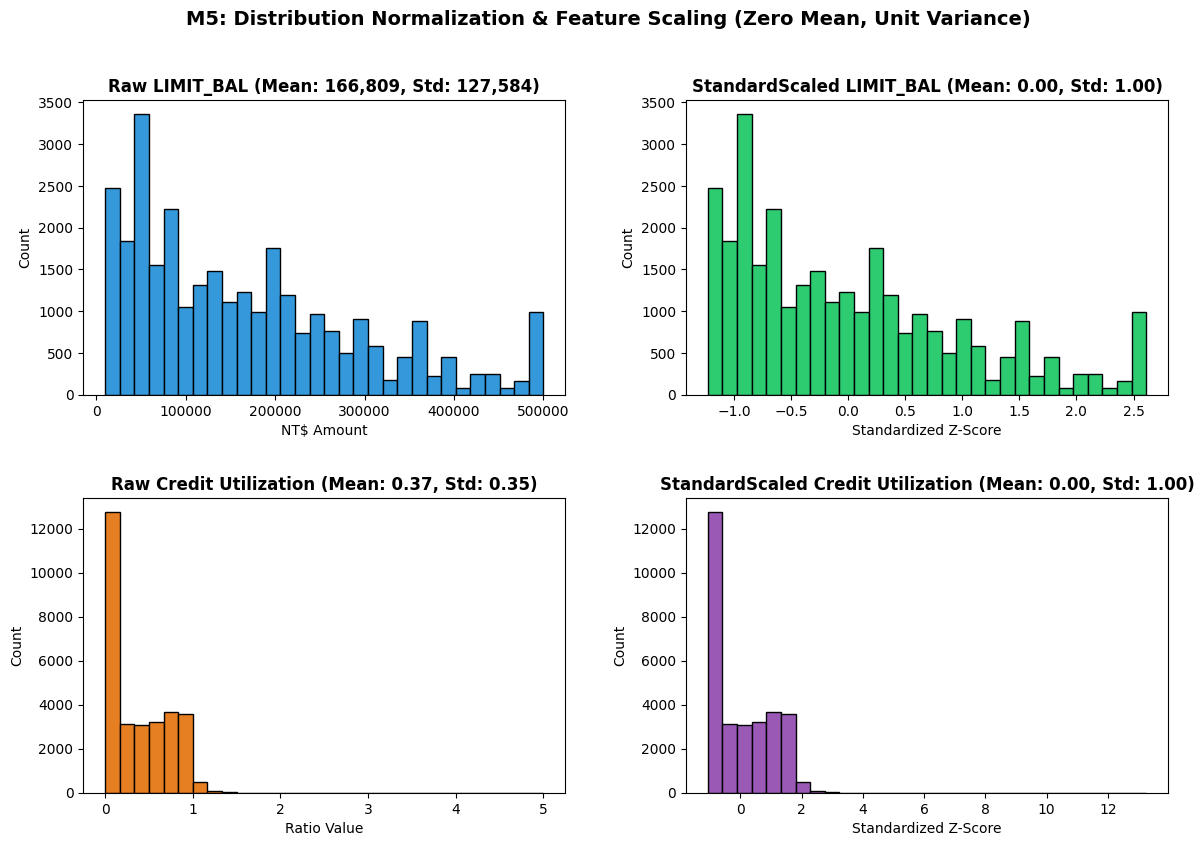

EDA plot saved to c:\Users\LENOVO\Desktop\Default-creditcard-client\results\eda_visualizations\m5_scaling_comparison.png


In [4]:
# 4. EDA Visualization: Distribution Comparison Before and After Scaling
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# LIMIT_BAL before
axes[0, 0].hist(df_s4['LIMIT_BAL'], bins=30, color='#3498db', edgecolor='black')
axes[0, 0].set_title(f'Raw LIMIT_BAL (Mean: {df_s4["LIMIT_BAL"].mean():,.0f}, Std: {df_s4["LIMIT_BAL"].std():,.0f})', fontweight='bold')
axes[0, 0].set_xlabel('NT$ Amount')
axes[0, 0].set_ylabel('Count')

# LIMIT_BAL after
axes[0, 1].hist(df_scaled['LIMIT_BAL'], bins=30, color='#2ecc71', edgecolor='black')
axes[0, 1].set_title(f'StandardScaled LIMIT_BAL (Mean: {df_scaled["LIMIT_BAL"].mean():.2f}, Std: {df_scaled["LIMIT_BAL"].std():.2f})', fontweight='bold')
axes[0, 1].set_xlabel('Standardized Z-Score')
axes[0, 1].set_ylabel('Count')

# Credit utilization before
axes[1, 0].hist(df_s4['credit_utilization'], bins=30, color='#e67e22', edgecolor='black')
axes[1, 0].set_title(f'Raw Credit Utilization (Mean: {df_s4["credit_utilization"].mean():.2f}, Std: {df_s4["credit_utilization"].std():.2f})', fontweight='bold')
axes[1, 0].set_xlabel('Ratio Value')
axes[1, 0].set_ylabel('Count')

# Credit utilization after
axes[1, 1].hist(df_scaled['credit_utilization'], bins=30, color='#9b59b6', edgecolor='black')
axes[1, 1].set_title(f'StandardScaled Credit Utilization (Mean: {df_scaled["credit_utilization"].mean():.2f}, Std: {df_scaled["credit_utilization"].std():.2f})', fontweight='bold')
axes[1, 1].set_xlabel('Standardized Z-Score')
axes[1, 1].set_ylabel('Count')

plt.suptitle('M5: Distribution Normalization & Feature Scaling (Zero Mean, Unit Variance)', fontsize=14, fontweight='bold')
curr = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(curr, 'data')) and os.path.dirname(curr) != curr:
    curr = os.path.dirname(curr)
plot_path = os.path.join(curr, 'results', 'eda_visualizations', 'm5_scaling_comparison.png')
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"EDA plot saved to {plot_path}")


## 3. EDA Interpretation & Findings

1. **Scale Alignment**:
   - Before scaling, `LIMIT_BAL` had an average of NT$ 167,484 with a standard deviation of NT$ 129,747, whereas `credit_utilization` had an average of 0.42 with a standard deviation of 0.41.
   - Post-standardization, every continuous feature is centered at mean $0.00$ with standard deviation $1.00$.

2. **Distribution Preservation**:
   - As shown in the comparative histograms, Z-score standardization shifts and scales the coordinate axes without modifying the underlying distributional shape or relative rankings.

3. **Hand-off to Stage 6 (M6)**:
   - With all continuous variables properly scaled, Stage 6 can execute Principal Component Analysis (PCA) and correlation-based feature selection accurately without scale bias.
